In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models 
import matplotlib.pyplot as plt
import tensorflow.keras.preprocessing.image as ImageDataGenerator


In [3]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255, 
    horizontal_flip=True, 
    zoom_range=0.2
)
train_datagen.flow_from_directory('dataset/train', target_size=(150, 150), batch_size=32, class_mode='binary')

Found 1506 images belonging to 3 classes.


In [4]:
IMAGE_SIZE =  256 
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50

In [5]:
train_generator = train_datagen.flow_from_directory('dataset/train', target_size=(IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE, class_mode='sparse')

Found 1506 images belonging to 3 classes.


In [ ]:
for image_batch, label_batch in train_generator:
    print(image_batch.shape)
    print(label_batch.shape)
    break

In [ ]:
dataset = tf.keras.preprocessing.image_dataset_from_directory("PlantVillage", shuffle=True, image_size=(256, 256), batch_size=32) # dataset is a tf.data.Dataset object that contains batches of images and their corresponding labels. The images are resized to 256x256 pixels, and the batch size is set to 32. The shuffle parameter is set to True, which means that the order of the images will be randomized each time the dataset is iterated over.

Found 2152 files belonging to 3 classes.


In [172]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [173]:
for image_batch, label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch.shape)
    print(image_batch[0])

    

(32, 256, 256, 3)
(32,)
tf.Tensor(
[[[175. 164. 170.]
  [173. 162. 168.]
  [172. 161. 167.]
  ...
  [131. 119. 119.]
  [140. 128. 128.]
  [154. 142. 142.]]

 [[160. 149. 155.]
  [174. 163. 169.]
  [171. 160. 166.]
  ...
  [125. 113. 113.]
  [131. 119. 119.]
  [140. 128. 128.]]

 [[163. 152. 158.]
  [178. 167. 173.]
  [163. 152. 158.]
  ...
  [129. 117. 117.]
  [135. 123. 123.]
  [138. 126. 126.]]

 ...

 [[173. 163. 162.]
  [175. 165. 164.]
  [177. 167. 166.]
  ...
  [146. 128. 128.]
  [127. 109. 109.]
  [145. 127. 127.]]

 [[175. 165. 164.]
  [176. 166. 165.]
  [176. 166. 165.]
  ...
  [158. 140. 140.]
  [145. 127. 127.]
  [137. 119. 119.]]

 [[175. 165. 164.]
  [174. 164. 163.]
  [172. 162. 161.]
  ...
  [143. 125. 125.]
  [131. 113. 113.]
  [134. 116. 116.]]], shape=(256, 256, 3), dtype=float32)


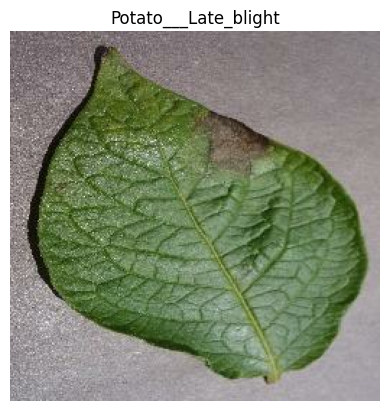

In [174]:
for image_batch, label_batch in dataset.take(1):
        plt.imshow(image_batch[0].numpy().astype("uint8"))
        plt.axis("off")
        plt.title(class_names[label_batch[0]])

In [175]:
len(dataset)

train_size = int(0.8* len(dataset))
train_size

54

In [176]:
train_ds = dataset.take(train_size)
len(train_ds)

54

In [177]:
test_ds = dataset.skip(train_size)
len(test_ds)

14

In [178]:
#validation\
val_ds = test_ds.take(int(0.5* len(test_ds)))
len(val_ds)

7

In [179]:
test_ds = test_ds.skip(int(0.5* len(test_ds)))
len(test_ds)

7

In [180]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [181]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [182]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
resize_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./255)
    
]) # resize_rescale is a sequential model that consists of two layers: Resizing and Rescaling. The Resizing layer resizes the input images to the specified IMAGE_SIZE (256x256 pixels in this case). The Rescaling layer scales the pixel values of the images to the range [0, 1] by dividing them by 255. This preprocessing step is commonly used in image classification tasks to normalize the input data and improve the performance of the model.


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
    ]) # data_augmentation is a sequential model that consists of several layers for data augmentation. The RandomFlip layer randomly flips the input images horizontally. The RandomRotation layer randomly rotates the images by a specified angle (0.1 radians in this case). The RandomZoom layer randomly zooms in on the images by a specified factor (0.1 in this case). The RandomContrast layer randomly adjusts the contrast of the images by a specified factor (0.1 in this case). Data augmentation is a technique used to artificially increase the size of the training dataset by applying random transformations to the input images, which can help improve the generalization of the model.

In [185]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3
model = models.Sequential([
    resize_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])
single_image_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
model.build(input_shape=(None,) + single_image_shape) # Build the model by specifying the input shape. The input shape is defined as (None, IMAGE_SIZE, IMAGE_SIZE, CHANNELS), where None indicates that the batch size can be variable. This allows the model to accept batches of images with different sizes during training and inference.

In [187]:
model.summary()

Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_34 (Sequential)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_75 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_76 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_77 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_78 (Conv2D)              │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_78 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_79 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_80 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_80 (MaxPooling2D) │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [188]:
model.compile(optimizer="adam", 
            loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
            metrics=["accuracy"])

history = model.fit(train_ds, validation_data=val_ds, batch_size=BATCH_SIZE, epochs=EPOCHS, verbose=1)



Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 57s 983ms/step - accuracy: 0.4925 - loss: 0.9008 - val_accuracy: 0.5156 - val_loss: 0.8342
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 50s 921ms/step - accuracy: 0.7407 - loss: 0.6288 - val_accuracy: 0.6875 - val_loss: 0.8231
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 50s 921ms/step - accuracy: 0.7940 - loss: 0.4821 - val_accuracy: 0.7969 - val_loss: 0.4401
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 46s 835ms/step - accuracy: 0.8443 - loss: 0.3703 - val_accuracy: 0.9219 - val_loss: 0.2224
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 50s 924ms/step - accuracy: 0.8709 - loss: 0.3344 - val_accuracy: 0.9219 - val_loss: 0.2369
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 51s 939ms/step - accuracy: 0.8848 - loss: 0.2790 - val_accuracy: 0.9010 - val_loss: 0.2496
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 49s 907ms/step - accuracy: 0.9138 - loss: 0.2241 - val_accuracy: 0.9375 - val_loss: 0.1904
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 49s 907ms/step - accuracy: 0.9225 - loss: 0.2027 - val_accu

In [191]:
scores = model.evaluate(test_ds)
scores

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 213ms/step - accuracy: 0.9531 - loss: 0.1116


[0.11157666146755219, 0.953125]

In [194]:
acc= history.history['accuracy']
loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

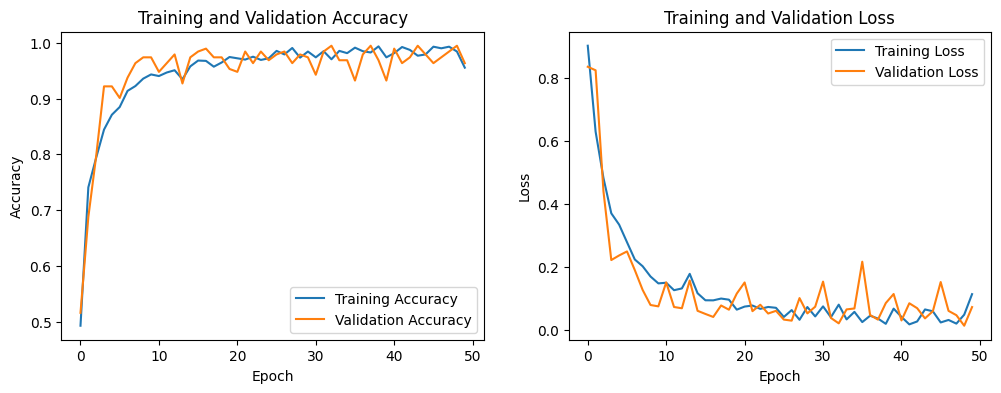

In [195]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

first image to predict
actual label: Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step
predicted label: Potato___Late_blight


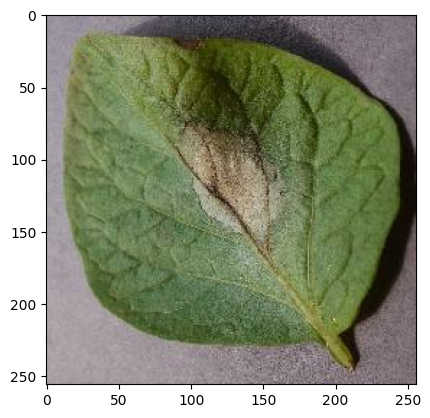

In [196]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
    
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

In [197]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images_batch[img ].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


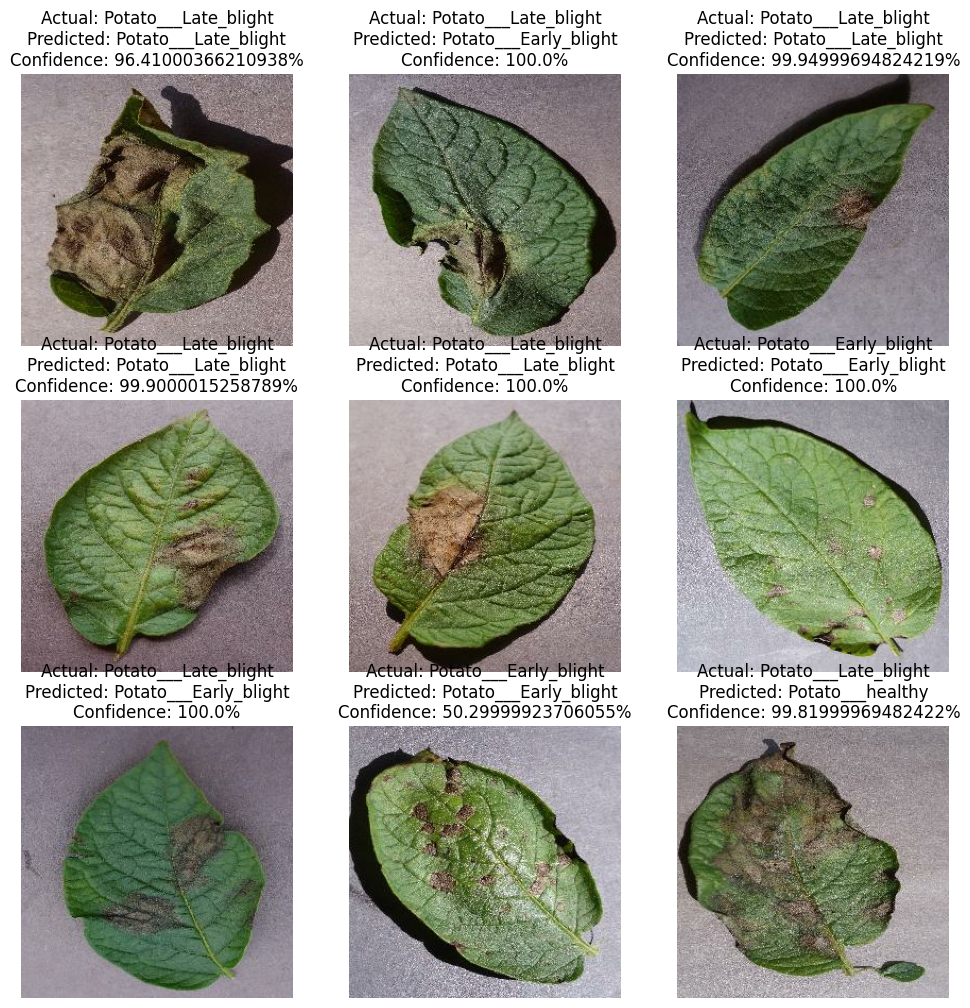

In [199]:
plt.figure(figsize=(12, 12))
for images,labels in test_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")
        predicted_class, confidence = predict(model, i)
        actual_class = class_names[labels[i].numpy()]
        plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence}%")

In [211]:
import os
model_version = max([int(i.split('.')[0]) for i in os.listdir("../models") if i.split('.')[0].isdigit()] + [0]) + 1

# Save with the .keras extension
model.save(f"../models/{model_version}.keras")